In [4]:
## Water Quality Classification

<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2021/08/Machine-Learning-Project-on-Water-Quality-Analysis.png?resize=1024%2C576&ssl=1"/>

In [1]:
#!pip install pycaret[full]

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

In [3]:
data = pd.read_csv("data/water_potability.csv")
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
data = data.dropna()
data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

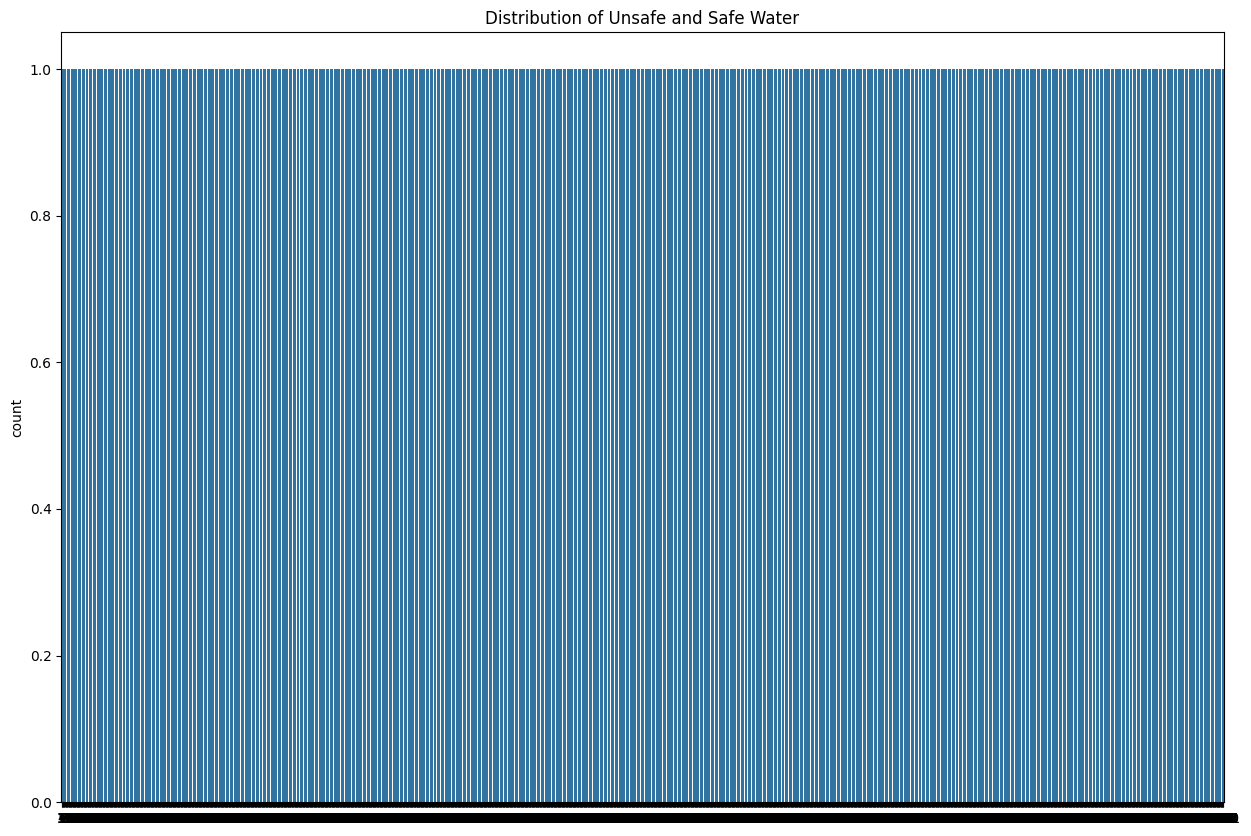

In [5]:
plt.figure(figsize=(15, 10))
sns.countplot(data.Potability)
plt.title("Distribution of Unsafe and Safe Water")
plt.show()

In [6]:
import plotly.express as px
data = data
figure = px.histogram(data, x = "ph", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: PH")
figure.show()

In [7]:
figure = px.histogram(data, x = "Hardness", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Hardness")
figure.show()

In [8]:
figure = px.histogram(data, x = "Solids", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Solids")
figure.show()

In [9]:
figure = px.histogram(data, x = "Chloramines", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Chloramines")
figure.show()

In [10]:
figure = px.histogram(data, x = "Sulfate", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Sulfate")
figure.show()

In [11]:
figure = px.histogram(data, x = "Conductivity", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Conductivity")
figure.show()

In [12]:
figure = px.histogram(data, x = "Organic_carbon", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Organic Carbon")
figure.show()

In [13]:

figure = px.histogram(data, x = "Trihalomethanes", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Trihalomethanes")
figure.show()

In [14]:
figure = px.histogram(data, x = "Turbidity", 
                      color = "Potability", 
                      title= "Factors Affecting Water Quality: Turbidity")
figure.show()

In [15]:
correlation = data.corr()
correlation["ph"].sort_values(ascending=False)

ph                 1.000000
Hardness           0.108948
Organic_carbon     0.028375
Trihalomethanes    0.018278
Potability         0.014530
Conductivity       0.014128
Sulfate            0.010524
Chloramines       -0.024768
Turbidity         -0.035849
Solids            -0.087615
Name: ph, dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [17]:
# 1. Veriyi Hazırlama (Target: Potability)
X = data.drop('Potability', axis=1)
y = data['Potability']

In [18]:
# 2. Eğitim ve Test Setlerine Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=786)

In [19]:
# 3. Model Oluşturma (RF) ve Eğitme
# create_model("rf") karşılığı:
rf_model = RandomForestClassifier(n_estimators=100, random_state=786)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# 4. Tahmin Yapma
# predict_model(model, data=data) karşılığı:
y_pred = rf_model.predict(X_test)

In [21]:
# 5. Sonuçları Görüntüleme
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.6699751861042184

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       241
           1       0.63      0.43      0.51       162

    accuracy                           0.67       403
   macro avg       0.66      0.63      0.63       403
weighted avg       0.66      0.67      0.65       403



In [22]:
# İlk 5 tahmini PyCaret formatında görmek istersen:
results = X_test.copy()
results['Actual'] = y_test
results['Prediction'] = y_pred
print("\nTahmin Sonuçları (İlk 5):")
print(results.head())


Tahmin Sonuçları (İlk 5):
             ph    Hardness        Solids  Chloramines     Sulfate  \
443    7.858663  210.954754  26703.853473     6.509065  341.341899   
2317   8.309228  198.336900  24344.966693     8.343510  278.866835   
1113   8.775486  157.354289  22113.391452     7.931503  304.807845   
47    10.682966  173.375498  15758.740621     5.570784  307.352586   
1066   8.567044  160.217867  23683.110190     4.286930  360.286282   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Actual  \
443     374.072845        8.811986        72.799798   3.422471       0   
2317    456.530019       15.514119        64.444751   3.756397       1   
1113    480.715208       15.692839        82.929345   4.393944       1   
47      323.807913       10.090870        78.472784   3.999775       0   
1066    490.512539        9.027167        67.476229   2.804927       0   

      Prediction  
443            0  
2317           1  
1113           1  
47             0  
1066        

In [23]:
import joblib

# Modeli 'water_model.joblib' adıyla kaydet
joblib.dump(rf_model, 'water_model.joblib')

print("Model başarıyla kaydedildi!")

Model başarıyla kaydedildi!


In [25]:
# --- Temel Metrikler ---
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 45)
print("        PERFORMANS METRİKLERİ")
print("=" * 45)
print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision  : {precision_score(y_test, y_pred):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score   : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["İçilemez (0)", "İçilebilir (1)"]))

        PERFORMANS METRİKLERİ
Accuracy   : 0.6700
Precision  : 0.6330
Recall     : 0.4259
F1-Score   : 0.5092
ROC-AUC    : 0.7042

Classification Report:
                precision    recall  f1-score   support

  İçilemez (0)       0.68      0.83      0.75       241
İçilebilir (1)       0.63      0.43      0.51       162

      accuracy                           0.67       403
     macro avg       0.66      0.63      0.63       403
  weighted avg       0.66      0.67      0.65       403



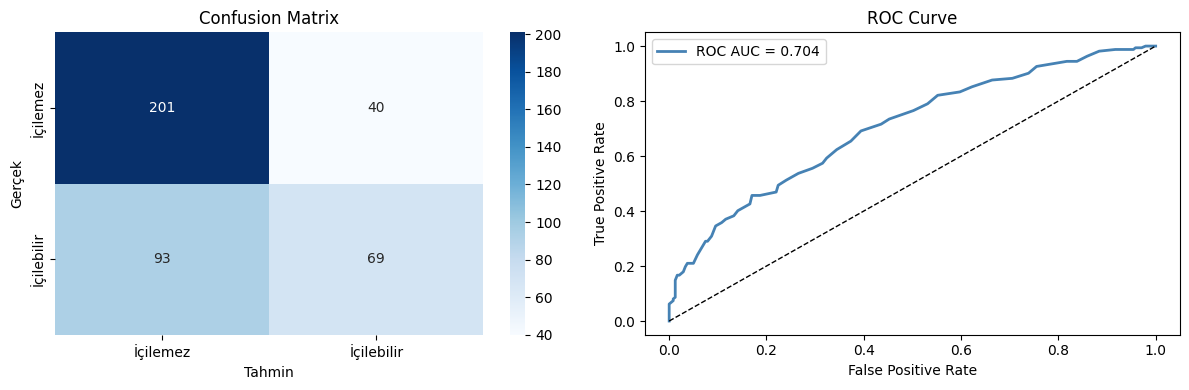

In [27]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["İçilemez", "İçilebilir"],
            yticklabels=["İçilemez", "İçilebilir"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Gerçek")
axes[0].set_xlabel("Tahmin")


# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

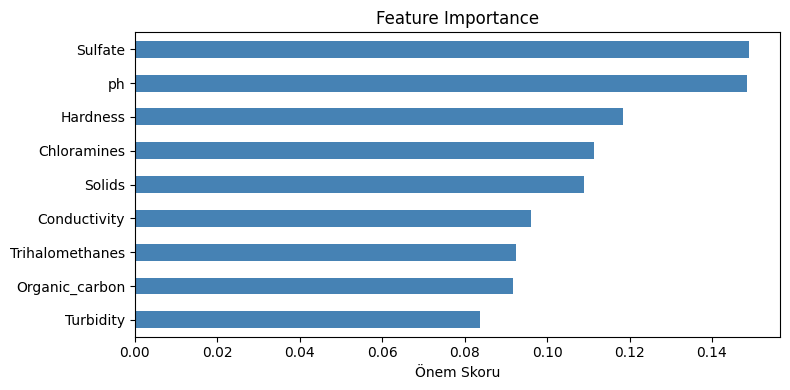

In [28]:
# --- Feature Importance ---
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values()
plt.figure(figsize=(8, 4))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation
Values from the Confusion Matrix:
Predicted: Not PotablePredicted: PotableActual: Not Potable201 (TP)40 (FN)Actual: Potable93 (FP)69 (TN)
What does it mean?
The model is very good at detecting non-potable water — correctly classified 201 out of 241 samples (83% recall). However, it struggles with potable water — only identified 69 out of 162 correctly (43% recall). The model is somewhat aggressive about predicting "not potable", misclassifying 93 actually safe water samples as unsafe.
This is likely caused by class imbalance — if the training data had more non-potable samples, the model naturally leans toward that class.

## ROC Curve Interpretation
ROC AUC = 0.704
AUC RangeInterpretation0.5Random guessing0.6 – 0.7Poor0.7 – 0.8Acceptable ✓0.8 – 0.9Good0.9+Excellent
A score of 0.704 means the model is meaningfully better than random, but not yet a strong classifier. The curve rises quickly at low FPR values but flattens out in the middle range.

## Overall Assessment
The main weakness is missing potable water samples (93 false positives). In a drinking water safety context, this matters — calling safe water unsafe is tolerable, but calling unsafe water safe is dangerous. From that angle, the model shows a safety-conscious bias, which is actually reasonable for this use case.
To improve performance, consider trying class_weight='balanced', collecting more data, or tuning the decision threshold.Sonnet 4.6